In [ ]:
##### 해당 파일은 코랩환경에서 작업했습니다 #####

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.losses import CTC
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
path_info = pd.read_csv('path_info.csv')

In [ ]:
len(path_info)

141658

In [ ]:
x_data = np.load('x_data_t312_m128_s156.npy')
y_data = np.load('y_data_t312_m128_s156.npy')
x_data_length = np.load('x_data_length_t312_m128_s156.npy')
y_data_length = np.load('y_data_length_t312_m128_s156.npy')

In [ ]:
x_data.shape, y_data.shape, x_data_length.shape, y_data_length.shape

((141658, 312, 128), (141658, 156), (141658,), (141658,))

In [ ]:
total_len = 156

bool_mask_list = []

for length in x_data_length:
  length = int(length/2)
  arr = np.zeros(total_len, dtype=int)
  arr[:length] = 1
  bool_arr = arr.astype(bool)
  bool_mask_list.append(bool_arr)

bool_mask = np.array(bool_mask_list)
bool_mask.shape

(141658, 156)

In [ ]:
# 미리 split한 Train,Validation,Test set 불러오기
train_idx = np.load('train_idx_list_128.npy')
val_idx = np.load('val_idx_list_128.npy')
test_idx = np.load('test_idx_list_128.npy')

In [ ]:
# GRU Attention GRU
@tf.keras.utils.register_keras_serializable(package="hardtanh")
def hardtanh(x, min_val=-20.0, max_val=20.0):
    return tf.clip_by_value(x, min_val, max_val)

def build_deepspeech2(input_shape=(312, 128, 1), num_classes=55):
    inputs = tf.keras.Input(shape=input_shape, name="input")
    mask_1 = tf.keras.Input(shape=(156,), dtype=tf.bool, name="mask_1")

    # 1. Feature Extractor (MaskCNN)
    conv2d_1 = layers.Conv2D(32, kernel_size=(11, 41), strides=(2, 2), padding='same', use_bias=False)
    conv2d_1_out = conv2d_1(inputs)
    BatNor_1 = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)
    BatNor_1_out = BatNor_1(conv2d_1_out)
    hardtanh_1 = layers.Activation(hardtanh)
    hardtanh_1_out = hardtanh_1(BatNor_1_out)

    conv2d_2 = layers.Conv2D(32, kernel_size=(11, 21), strides=(1, 2), padding='same', use_bias=False)
    conv2d_2_out = conv2d_2(hardtanh_1_out)
    BatNor_2 = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)
    BatNor_2_out = BatNor_2(conv2d_2_out)
    hardtanh_2 = layers.Activation(hardtanh)
    hardtanh_2_out = hardtanh_2(BatNor_2_out)

    # 2. Reshape for RNN
    b, t, f, c = hardtanh_2_out.shape  # batch, time, freq, channel
    Reshape_1 = layers.Reshape((-1, f * c))
    Reshape_1_out = Reshape_1(hardtanh_2_out)  # merge freq and channel

    # 3. RNN Layers
    BatNor_3 = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)
    BatNor_3_out = BatNor_3(Reshape_1_out)
    GRU_1 = layers.Bidirectional(layers.GRU(512,
                                        return_sequences=True,
                                        dropout=0.1
                                        ),
                              merge_mode='concat'
                              )
    GRU_1_out = GRU_1(BatNor_3_out, mask=mask_1)

    Att_1 = layers.Attention()
    Att_1_out = Att_1([GRU_1_out,GRU_1_out])

    BatNor_4 = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)
    BatNor_4_out = BatNor_4(Att_1_out)
    GRU_2 = layers.Bidirectional(layers.GRU(512,
                                        return_sequences=True,
                                        dropout=0.1
                                        ),
                              merge_mode='concat'
                              )
    GRU_2_out = GRU_2(BatNor_4_out, mask=mask_1)

    Att_2 = layers.Attention()
    Att_2_out = Att_2([GRU_2_out,GRU_2_out])

    BatNor_5 = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)
    BatNor_5_out = BatNor_5(Att_2_out)
    GRU_3 = layers.Bidirectional(layers.GRU(512,
                                        return_sequences=True,
                                        dropout=0.1
                                        ),
                              merge_mode='concat'
                              )
    GRU_3_out = GRU_3(BatNor_5_out, mask=mask_1)


    # 4. Fully Connected
    LayNor_1 = layers.LayerNormalization()
    LayNor_1_out = LayNor_1(GRU_3_out)
    dense_1 = layers.Dense(num_classes, use_bias=False)
    dense_1_out = dense_1(LayNor_1_out)

    return tf.keras.Model(inputs=[inputs,mask_1], outputs=dense_1_out)

# 모델 생성
rnn_Att_rnn_model = build_deepspeech2(input_shape=(312, 128, 1))
rnn_Att_rnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=CTC(), metrics=['accuracy'])

rnn_Att_rnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 312, 128,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 156, 64,   │     14,432 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 156, 64,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 156, 64,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 156, 32,   │    236,544 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 156, 32,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 156, 32,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 156, 1024) │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 156, 1024) │      4,096 │ reshape[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_1 (InputLayer) │ (None, 156)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 156, 1024) │  4,724,736 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │ mask_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 156, 1024) │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 156, 1024) │      4,096 │ attention[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 156, 1024) │  4,724,736 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │ mask_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 156, 1024) │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 156, 1024) │      4,096 │ attention_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 156, 1024) │  4,724,736 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │ mask_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,496,096 (55.30 MB)

 Trainable params: 14,489,824 (55.27 MB)

 Non-trainable params: 6,272 (24.50 KB)

In [ ]:
# 저장 폴더 지정

save_folder = '2)mask_rnn_Att_rnn_model'
save_path = f"/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/{save_folder}"

In [ ]:
# 최초 학습

# train_valid set 랜덤 지정
train_x_data = x_data[train_idx]
train_mask_data = bool_mask[train_idx]
train_y_data = y_data[train_idx]
valid_x_data = x_data[val_idx]
valid_mask_data = bool_mask[val_idx]
valid_y_data = y_data[val_idx]
test_x_data = x_data[test_idx]
test_mask_data = bool_mask[test_idx]
test_y_data = y_data[test_idx]

train_model = rnn_Att_rnn_model.fit([train_x_data,train_mask_data],
                        train_y_data,
                        batch_size=256,
                        validation_data=([valid_x_data,valid_mask_data], valid_y_data),
                        # validation_split=0.1,
                        epochs=500,
                        callbacks=[EarlyStopping(monitor='val_loss',patience=10),
                                  ModelCheckpoint(filepath=save_path+'/STT_simple_attention.keras', monitor='val_loss', save_best_only=True, verbose=1)]
                        )

Epoch 1/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5374 - loss: 197.7762
Epoch 1: val_loss improved from inf to 151.06197, saving model to /content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/2)mask_rnn_Att_rnn_model/STT_simple_attention.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 728s 2s/step - accuracy: 0.5374 - loss: 197.7155 - val_accuracy: 0.5290 - val_loss: 151.0620
Epoch 2/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5348 - loss: 149.4363
Epoch 2: val_loss improved from 151.06197 to 136.98143, saving model to /content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/2)mask_rnn_Att_rnn_model/STT_simple_attention.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 713s 2s/step - accuracy: 0.5348 - loss: 149.4275 - val_accuracy: 0.5390 - val_loss: 136.9814
Epoch 3/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5225 - loss: 133.3826
Epoch 3: val_loss improved from 136.98143 to 118.43182, saving model to /content/drive/MyDrive/Sesac/한

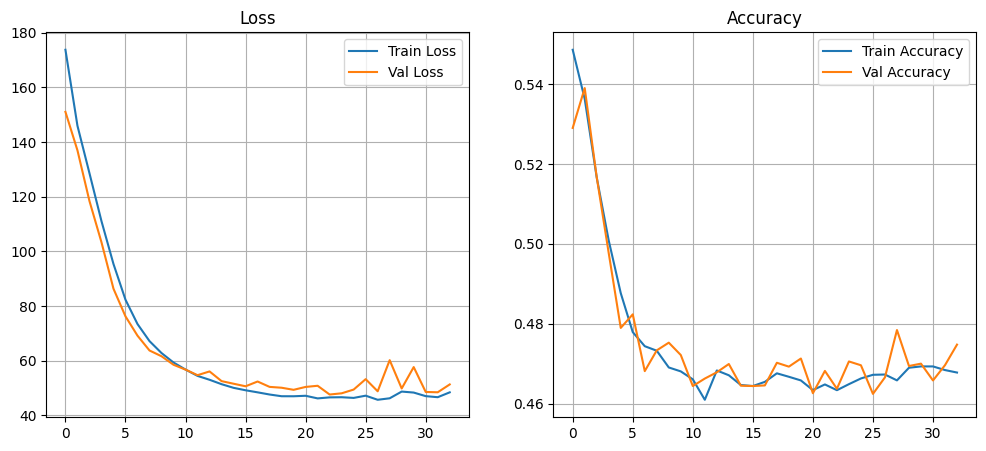

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax[0].plot(train_model.history['loss'], label='Train Loss')
ax[0].plot(train_model.history['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(train_model.history['accuracy'], label='Train Accuracy')
ax[1].plot(train_model.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.show()
plt.savefig(f'/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/{save_folder}/{train_model.history['val_loss'][-11]}.png')